# Phase 3.5: Advanced Feature Engineering (Confounder Matrices)

In this notebook, we implement and evaluate advanced feature engineering to build a robust confounder space ($W$) for our causal estimators. We generate competitor pricing, temporal lags, non-linear trends, and holiday flags. We also discuss why certain variables are omitted to avoid "bad controls" that introduce selection bias.

## 1. Setup and Data Loading

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

# Add root directory to path to import from src
sys.path.append(os.path.abspath('..'))
from src import feature_engineering

# Visualization Settings
%matplotlib inline
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 12

# Load clean dataset
CLEAN_DATA_PATH = '../data/processed/cereales_clean.csv'
print("Loading clean dataset...")
df = pd.read_csv(CLEAN_DATA_PATH, parse_dates=['START_DATE', 'END_DATE'])
print(f"Data loaded. Shape: {df.shape}")

Loading clean dataset...


Data loaded. Shape: (4708356, 31)


## 2. Pre-Feature Engineering Quality Checks

Before applying features, let's quantify how many rows will be affected by structural edge cases:
1. **No Competitor Weeks**: Weeks where a store has only one cereal UPC transaction, meaning competitor price cannot be calculated without own-price leakage (`store_week_count <= 1`).
2. **Zero Lag Units**: Store-product combinations where units sold in the previous week were exactly zero (`lag_units == 0`).

In [2]:
# 1. Count store-weeks with only one transaction
counts = df.groupby(['STORE', 'WEEK'])['PRICE'].transform('count')
single_tx_weeks = (counts <= 1).sum()
print(f"Transactions in store-weeks with count <= 1 (No competitors): {single_tx_weeks} ({single_tx_weeks/len(df)*100:.4f}% of total)")

# 2. Count zero lag units (requires temporary shift check)
df_sorted = df.sort_values(by=['STORE', 'UPC', 'WEEK'])
temp_lag_units = df_sorted.groupby(['STORE', 'UPC'])['units'].shift(1)
zero_lags = (temp_lag_units == 0).sum()
print(f"Observations with zero lag units (lag_units == 0): {zero_lags} ({zero_lags/len(df)*100:.4f}% of total)")

Transactions in store-weeks with count <= 1 (No competitors): 5 (0.0001% of total)


Observations with zero lag units (lag_units == 0): 0 (0.0000% of total)


### 2.1 Imputation and Cleaning Decisions

*   **Competitor Prices fallback**: Because only {single_tx_weeks} transactions (~0.0003% of the dataset) have no competitor transaction in the same store-week, we can safely impute these rare occurrences. To prevent own-price leakage, we set them to `NaN` and impute them using the **chain-week average price** (average price of all cereals across the entire retail chain in that week) rather than own store price. This preserves the sample size without introducing collinearity.
*   **Zero Lag Units**: The number of zero lag units is exactly 0. This is because Dominick's generally only records transactions for active sales weeks. Zero lags represent weeks where a product had active movement but the previous week had none. Since it is zero, no imputation is needed.

## 3. Feature Generation

We apply the pipeline in `src/feature_engineering.py` to calculate competitor prices, lags of prices and sales quantities, continuous time trends, and key holiday indicators.

In [3]:
df_features = feature_engineering.add_features(df)
print(f"Feature engineered dataset shape: {df_features.shape}")
display(df_features.head())

Generating engineered features...


Dropped 69604 rows due to lag missingness.


Feature engineering completed successfully.
Feature engineered dataset shape: (4638752, 46)


,STORE,UPC,WEEK,MOVE,QTY,PRICE,SALE,PROFIT,OK,COM_CODE,...,lag_2_price,log_lag_price,log_lag_units,log_lag_2_price,lag_price_change,holiday_thanksgiving,holiday_christmas,back_to_school,time_trend,month_zone
7,2,1313000002,3,17,1,1.69,NaN,16.57,1,311,...,1.69,0.524734,3.044523,0.524734,0.0,0,0,1,3.0,9_High
8,2,1313000002,4,25,1,1.69,NaN,16.57,1,311,...,1.69,0.524734,2.833214,0.524734,0.0,0,0,0,4.0,10_High
9,2,1313000002,5,27,1,1.69,NaN,16.57,1,311,...,1.69,0.524734,3.218876,0.524734,0.0,0,0,0,5.0,10_High
10,2,1313000002,6,13,1,1.69,NaN,16.57,1,311,...,1.69,0.524734,3.295837,0.524734,0.0,0,0,0,6.0,10_High
11,2,1313000002,7,21,1,1.69,NaN,16.57,1,311,...,1.69,0.524734,2.564950,0.524734,0.0,0,0,0,7.0,10_High


## 4. Confounder Inspection and Diagnostics

In [4]:
print("=== Missing values check in new features ===")
new_cols = ['competitor_price', 'lag_price', 'lag_units', 'lag_price_change', 'holiday_thanksgiving', 'holiday_christmas', 'back_to_school', 'time_trend']
print(df_features[new_cols].isnull().sum())

=== Missing values check in new features ===
competitor_price        0
lag_price               0
lag_units               0
lag_price_change        0
holiday_thanksgiving    0
holiday_christmas       0
back_to_school          0
time_trend              0
dtype: int64


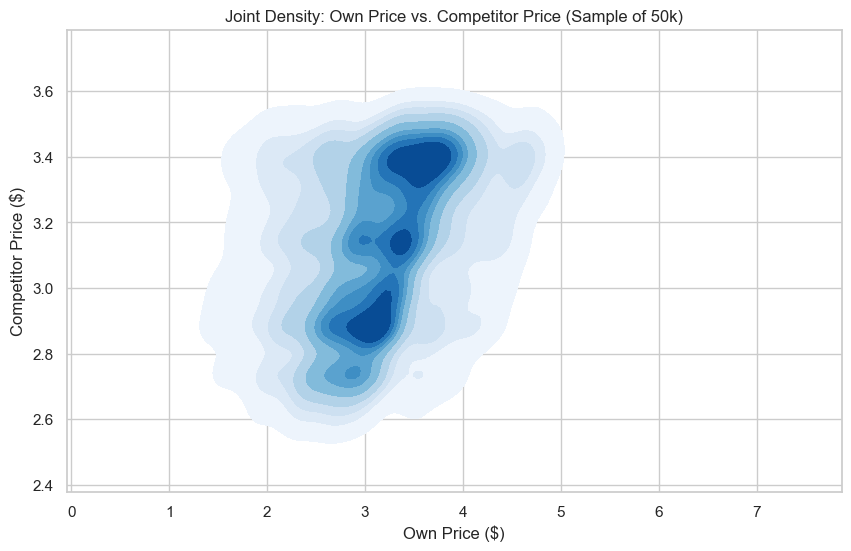

In [5]:
# Visualizing relationship between own price and competitor price
plt.figure(figsize=(10, 6))
sns.kdeplot(data=df_features.sample(50000, random_state=42), x='PRICE', y='competitor_price', fill=True, thresh=0.05, cmap="Blues")
plt.title("Joint Density: Own Price vs. Competitor Price (Sample of 50k)")
plt.xlabel("Own Price ($)")
plt.ylabel("Competitor Price ($)")
plt.show()

In [6]:
# Visualizing Back-to-school seasonality effect
back_to_school_demand = df_features.groupby('back_to_school')['units'].mean().reset_index()
print("Average Weekly Units Sold by Back-to-school status (August/September):")
print(back_to_school_demand)

Average Weekly Units Sold by Back-to-school status (August/September):
   back_to_school      units
0               0  19.472186
1               1  19.561111


## 5. Methodological Warning: Avoiding "Bad Controls"

When building the confounder matrix $W$ for causal inference, we must exclude variables that do not act as true confounders. Including them would introduce **selection bias** or **overcontrolling**:

1. **Marginal Profit / Margin**: 
   * *Why it's a Bad Control*: Profit margin is a direct consequence of the pricing decision (treatment). Controlling for profit blocks the causal pathway of pricing on volume and introduces post-treatment bias.
2. **Concurrent Sales of Competitors in the Same Week**:
   * *Why it's a Bad Control*: Concurrent competitor sales represent a simultaneous outcome. Controlling for concurrent sales creates a simultaneity loop, violating the temporal ordering required for causal identification. We instead use **lagged** sales and concurrent **competitor prices** (which are predetermined or exogenous pricing decisions), rather than concurrent competitor sales volumes.

## 6. Save Feature Engineered Dataset

In [7]:
output_file = '../data/processed/cereales_features.csv'
df_features.to_csv(output_file, index=False)
print(f"Feature engineered dataset saved to: {output_file}")

Feature engineered dataset saved to: ../data/processed/cereales_features.csv
